加载数据...
训练集大小: 1078
验证集大小: 359
测试集大小: 360

开始训练两层MLP

参数形状:
W1: (64, 128)
b1: (128,)
W2: (128, 10)
b2: (10,)

梯度形状:
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)

梯度形状:
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)

梯度形状:
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)

梯度形状:
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)

梯度形状:
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)

梯度形状:
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)

梯度形状:
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)

梯度形状:
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)

梯度形状:
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)

梯度形状:
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)

梯度形状:
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)

梯度形状:
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)

梯度形状:
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)

梯度形状:
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)

梯度形状:
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db

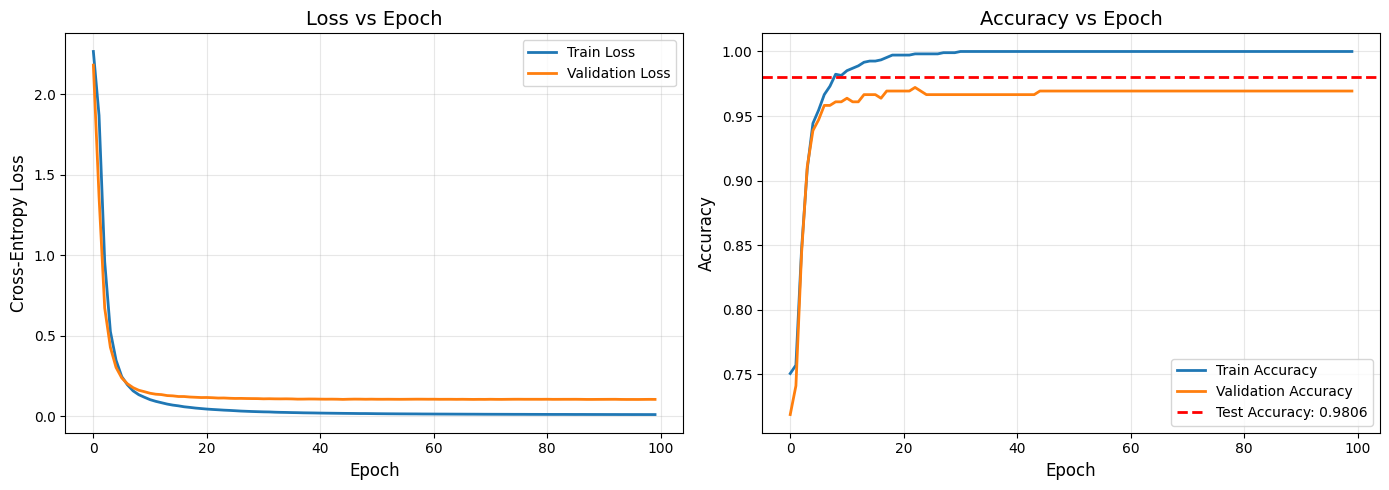


最终结果汇总
训练集准确率: 1.0000 (100.00%)
验证集准确率: 0.9694 (96.94%)
测试集准确率: 0.9806 (98.06%)
最终训练损失: 0.009741
最终验证损失: 0.104082


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 设置随机种子保证可重复性
np.random.seed(42)

# ==================== 1. 加载和预处理数据 ====================
print("加载数据...")
digits = load_digits()
X, y = digits.data, digits.target  # X: (1797, 64), y: (1797,)

# 划分数据集 train/val/test = 60/20/20
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"训练集大小: {X_train.shape[0]}")
print(f"验证集大小: {X_val.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")

# 标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 将标签转换为 one-hot 编码
def to_one_hot(y, num_classes=10):
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

y_train_onehot = to_one_hot(y_train)
y_val_onehot = to_one_hot(y_val)
y_test_onehot = to_one_hot(y_test)

# ==================== 2. 两层MLP类 ====================
class TwoLayerMLP:
    def __init__(self, input_dim, hidden_dim, output_dim):
        """
        初始化参数
        input_dim: 64
        hidden_dim: 128
        output_dim: 10
        """
        # 初始化权重和偏置
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.01  # (64, 128)
        self.b1 = np.zeros(hidden_dim)  # (128,)
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.01  # (128, 10)
        self.b2 = np.zeros(output_dim)  # (10,)

        # 打印参数形状
        print("\n参数形状:")
        print(f"W1: {self.W1.shape}")
        print(f"b1: {self.b1.shape}")
        print(f"W2: {self.W2.shape}")
        print(f"b2: {self.b2.shape}")

    def relu(self, x):
        """ReLU激活函数"""
        return np.maximum(0, x)

    def relu_derivative(self, x):
        """ReLU导数"""
        return (x > 0).astype(float)

    def softmax(self, x):
        """Softmax函数，带数值稳定性"""
        # 减去最大值防止溢出
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        """
        前向传播
        X: (B, D) 输入batch
        返回:
            Z1: (B, H)
            A1: (B, H)
            Z2: (B, C)
            P: (B, C) 预测概率
        """
        # a) Z1 = X @ W1 + b1
        self.Z1 = X @ self.W1 + self.b1  # (B, H)
        # b) A1 = relu(Z1)
        self.A1 = self.relu(self.Z1)  # (B, H)
        # c) Z2 = A1 @ W2 + b2
        self.Z2 = self.A1 @ self.W2 + self.b2  # (B, C)
        # d) P = softmax(Z2)
        self.P = self.softmax(self.Z2)  # (B, C)

        return self.P

    def compute_loss(self, P, y_onehot):
        """
        计算交叉熵损失
        P: (B, C) 预测概率
        y_onehot: (B, C) one-hot标签
        返回: 平均损失
        """
        # 添加小值防止log(0)
        eps = 1e-15
        P = np.clip(P, eps, 1 - eps)
        # 交叉熵损失
        loss = -np.sum(y_onehot * np.log(P)) / P.shape[0]
        return loss

    def backward(self, X, y_onehot, reg_lambda=0.0):
        """
        反向传播，计算梯度
        X: (B, D) 输入batch
        y_onehot: (B, C) one-hot标签
        reg_lambda: L2正则化系数
        返回: 梯度字典
        """
        batch_size = X.shape[0]

        # 输出层梯度
        # dL/dZ2 = P - y
        dZ2 = self.P - y_onehot  # (B, C)

        # dW2 = A1.T @ dZ2 / batch_size (+ 正则化梯度)
        dW2 = (self.A1.T @ dZ2) / batch_size
        if reg_lambda > 0:
            dW2 += reg_lambda * self.W2

        # db2 = sum(dZ2) / batch_size
        db2 = np.sum(dZ2, axis=0) / batch_size

        # 传播到隐藏层
        # dA1 = dZ2 @ W2.T
        dA1 = dZ2 @ self.W2.T  # (B, H)

        # dZ1 = dA1 * relu'(Z1)
        dZ1 = dA1 * self.relu_derivative(self.Z1)  # (B, H)

        # dW1 = X.T @ dZ1 / batch_size
        dW1 = (X.T @ dZ1) / batch_size
        if reg_lambda > 0:
            dW1 += reg_lambda * self.W1

        # db1 = sum(dZ1) / batch_size
        db1 = np.sum(dZ1, axis=0) / batch_size

        # 打印梯度形状
        print(f"\n梯度形状:")
        print(f"dW1: {dW1.shape}")
        print(f"db1: {db1.shape}")
        print(f"dW2: {dW2.shape}")
        print(f"db2: {db2.shape}")

        return {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}

    def update_params(self, grads, learning_rate):
        """梯度下降更新参数"""
        self.W1 -= learning_rate * grads['dW1']
        self.b1 -= learning_rate * grads['db1']
        self.W2 -= learning_rate * grads['dW2']
        self.b2 -= learning_rate * grads['db2']

    def predict(self, X):
        """预测类别"""
        P = self.forward(X)
        return np.argmax(P, axis=1)

    def accuracy(self, X, y):
        """计算准确率"""
        pred = self.predict(X)
        return np.mean(pred == y)

# ==================== 3. 训练函数 ====================
def train(model, X_train, y_train_onehot, X_val, y_val,
          epochs=100, batch_size=32, learning_rate=0.01,
          reg_lambda=0.0, verbose=True):
    """
    训练模型
    """
    n_samples = X_train.shape[0]
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        # 打乱数据
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train_onehot[indices]

        epoch_loss = 0
        num_batches = 0

        # Mini-batch 训练
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # 前向传播
            P = model.forward(X_batch)

            # 计算损失
            loss = model.compute_loss(P, y_batch)
            epoch_loss += loss
            num_batches += 1

            # 反向传播
            grads = model.backward(X_batch, y_batch, reg_lambda)

            # 更新参数
            model.update_params(grads, learning_rate)

        # 计算平均训练损失
        avg_train_loss = epoch_loss / num_batches
        train_losses.append(avg_train_loss)

        # 验证集评估
        P_val = model.forward(X_val)
        val_loss = model.compute_loss(P_val, to_one_hot(y_val))
        val_losses.append(val_loss)

        train_acc = model.accuracy(X_train, y_train)
        val_acc = model.accuracy(X_val, y_val)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - "
                  f"Train Loss: {avg_train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Train Acc: {train_acc:.4f}, "
                  f"Val Acc: {val_acc:.4f}")

    return train_losses, val_losses, train_accs, val_accs

# ==================== 4. 运行实验 ====================
print("\n" + "="*50)
print("开始训练两层MLP")
print("="*50)

# 创建模型
model = TwoLayerMLP(input_dim=64, hidden_dim=128, output_dim=10)

# 训练参数
EPOCHS = 100
BATCH_SIZE = 32
LEARNING_RATE = 0.1
REG_LAMBDA = 0.001  # 轻微L2正则化

# 训练
train_losses, val_losses, train_accs, val_accs = train(
    model, X_train, y_train_onehot, X_val, y_val,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE, reg_lambda=REG_LAMBDA,
    verbose=True
)

# 测试集评估
test_acc = model.accuracy(X_test, y_test)
print(f"\n测试集准确率: {test_acc:.4f} ({test_acc*100:.2f}%)")

# ==================== 5. 绘图 ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss曲线
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Cross-Entropy Loss', fontsize=12)
axes[0].set_title('Loss vs Epoch', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 准确率曲线
axes[1].plot(train_accs, label='Train Accuracy', linewidth=2)
axes[1].plot(val_accs, label='Validation Accuracy', linewidth=2)
axes[1].axhline(y=test_acc, color='r', linestyle='--',
                label=f'Test Accuracy: {test_acc:.4f}', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy vs Epoch', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印最终结果汇总
print("\n" + "="*50)
print("最终结果汇总")
print("="*50)
print(f"训练集准确率: {train_accs[-1]:.4f} ({train_accs[-1]*100:.2f}%)")
print(f"验证集准确率: {val_accs[-1]:.4f} ({val_accs[-1]*100:.2f}%)")
print(f"测试集准确率: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"最终训练损失: {train_losses[-1]:.6f}")
print(f"最终验证损失: {val_losses[-1]:.6f}")